In [1]:
import matplotlib as mpl
mpl.use('agg')
import sys; sys.path.insert(0,'/Users/ardasheva/Documents/NBI-postdoc/plottingTest')
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi, atan2, cos, sin
from massPy import archive 
from massPy.nematic import plot as nem_plot
from massPy.nematic import nematicPy as nem_tools
from massPy.utils import correlation as corr
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')
from scipy import ndimage
from scipy.ndimage import zoom as ndz

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

# number of domains

In [3]:
dataND = np.genfromtxt('../DATA/data-experiments/domainN/HH-NumberOfDomains.dat', delimiter=' ')

timeND = dataND[:,0]
valsND = dataND[:,1]

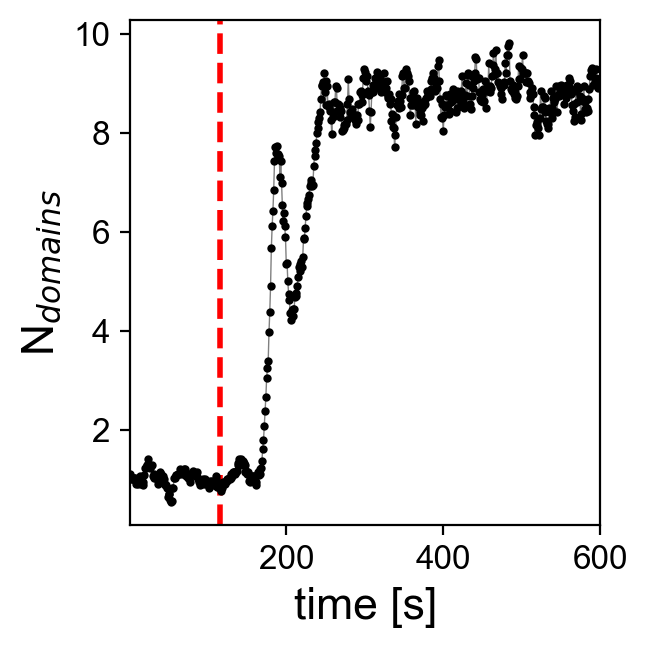

In [4]:
#normalisation
normND = np.asarray(np.mean(valsND[0:119]))

#plotting

f=plt.figure(figsize=(3.4,3.4),dpi=200)
ax = plt.subplot(111)

ax.axvline(x=115,color='r', lw=2, ls='--')
ax.plot(timeND,valsND/normND, color='grey',marker='.', markerfacecolor='k',markeredgecolor='k',markersize=4, lw=0.5)
ax.set_xlim([1,600])
ax.set_xlabel('time [s]', fontsize=16)
ax.set_ylabel('N$_{domains}$', fontsize=16)
    
plt.tight_layout()

plt.savefig('./figs/fig1/1d.svg')

# vrms

In [5]:
def calculVRMS(XX, Nt):
    rms = []

    for n in range(Nt):
        vy = np.loadtxt('../DATA/data-experiments/velocity/'+XX+'_vvel_'+str(n+1)+'.txt', delimiter=',')
        vx = np.loadtxt('../DATA/data-experiments/velocity/'+XX+'_uvel_'+str(n+1)+'.txt', delimiter=',')

        vrms = sqrt(np.mean(vx**2+vy**2))
        rms.append(vrms)
    
    return rms

In [6]:
vrmsHH = calculVRMS('HH', 399)

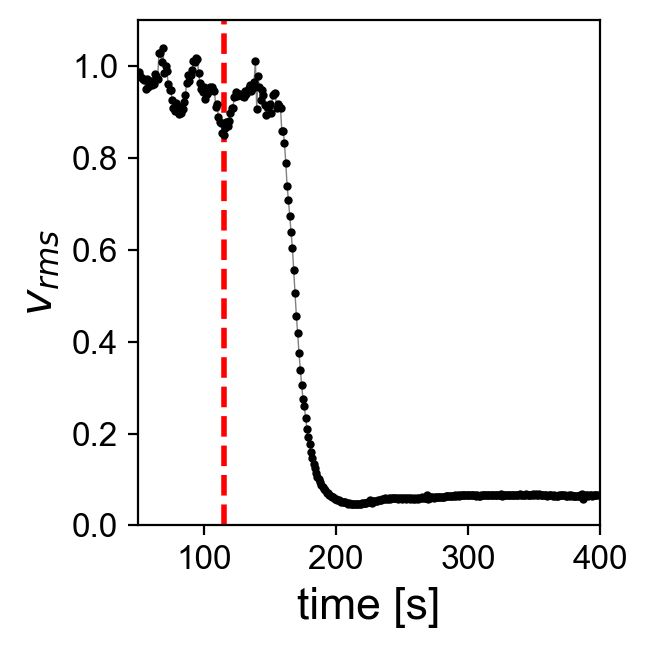

In [7]:
#normalisation
norm_c_vrms = np.asarray(np.mean(vrmsHH[0:119]))

#plotting
f=plt.figure(figsize=(3.4,3.4),dpi=200)
ax = plt.subplot(111)

ax.axvline(x=115,color='r', lw=2, ls='--')
ax.plot(vrmsHH/norm_c_vrms, color='grey',marker='.', markerfacecolor='k',markeredgecolor='k',markersize=4, lw=0.5)
ax.set_xlim([50,400])
ax.set_ylim([0,1.1])
ax.set_xlabel('time [s]', fontsize=16)
ax.set_ylabel('$v_{rms}$', fontsize=16)
    
plt.tight_layout()

plt.savefig('./figs/fig1/1c.svg')


# director correlation length

In [8]:
Nt = 599

Corrs = [[]]*Nt
Clen = []

for i in range(1,Nt):
    if len(str(i)) == 3:
        frn = '0'+str(i)
    elif len(str(i)) == 2:
        frn = '00'+str(i)
    elif len(str(i)) == 1:
        frn = '000'+str(i)

    S = np.genfromtxt('../DATA/data-experiments/fixed/HH/S-'+frn+'.csv', delimiter=',')
    THETA = np.genfromtxt('../DATA/data-experiments/fixed/HH/Theta-'+frn+'.csv', delimiter=',')

    THETAc=THETA
    nx = np.cos(THETAc)
    ny = np.sin(THETAc)

    C,r = corr.rdf2d2(nx[20:500,20:500],ny[20:500,20:500])
    
    for j in range(len(C)):
        if C[j] <= 1.0-1.0/2.71828:# or check location of minima
            
            cl = r[j]
            break
    
    Corrs[i-1] = C
    Clen.append(cl)

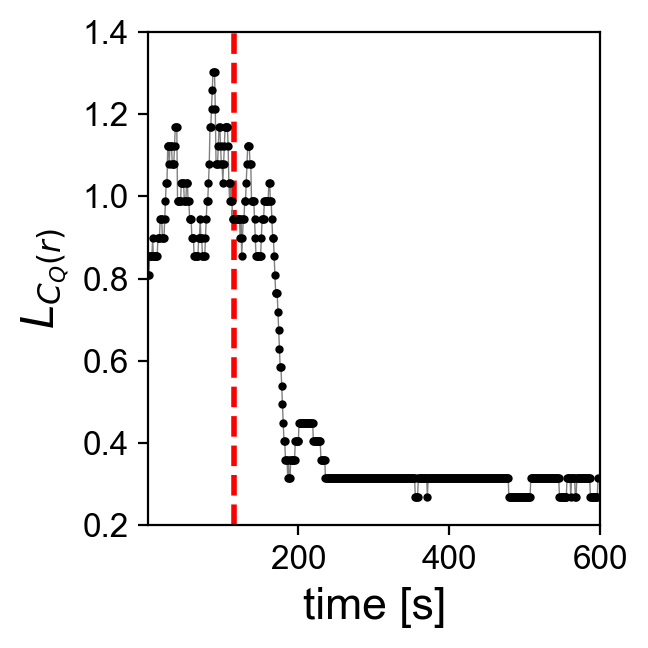

In [9]:
#normalisation
norm_c = np.asarray(np.mean(Clen[0:119]))

#plotting

f=plt.figure(figsize=(3.4,3.4),dpi=200)
ax = plt.subplot(111)

ax.axvline(x=115,color='r', lw=2, ls='--')
ax.plot(Clen/norm_c, color='grey',marker='.', markerfacecolor='k',markeredgecolor='k',markersize=4, lw=0.5)
ax.set_xlim([1,600])
ax.set_ylim([0.2,1.4])
ax.set_xlabel('time [s]', fontsize=16)
ax.set_ylabel('$L_{C_{Q}(r)}$', fontsize=16)
    
plt.tight_layout()

plt.savefig('./figs/fig1/1b.svg')

# combined

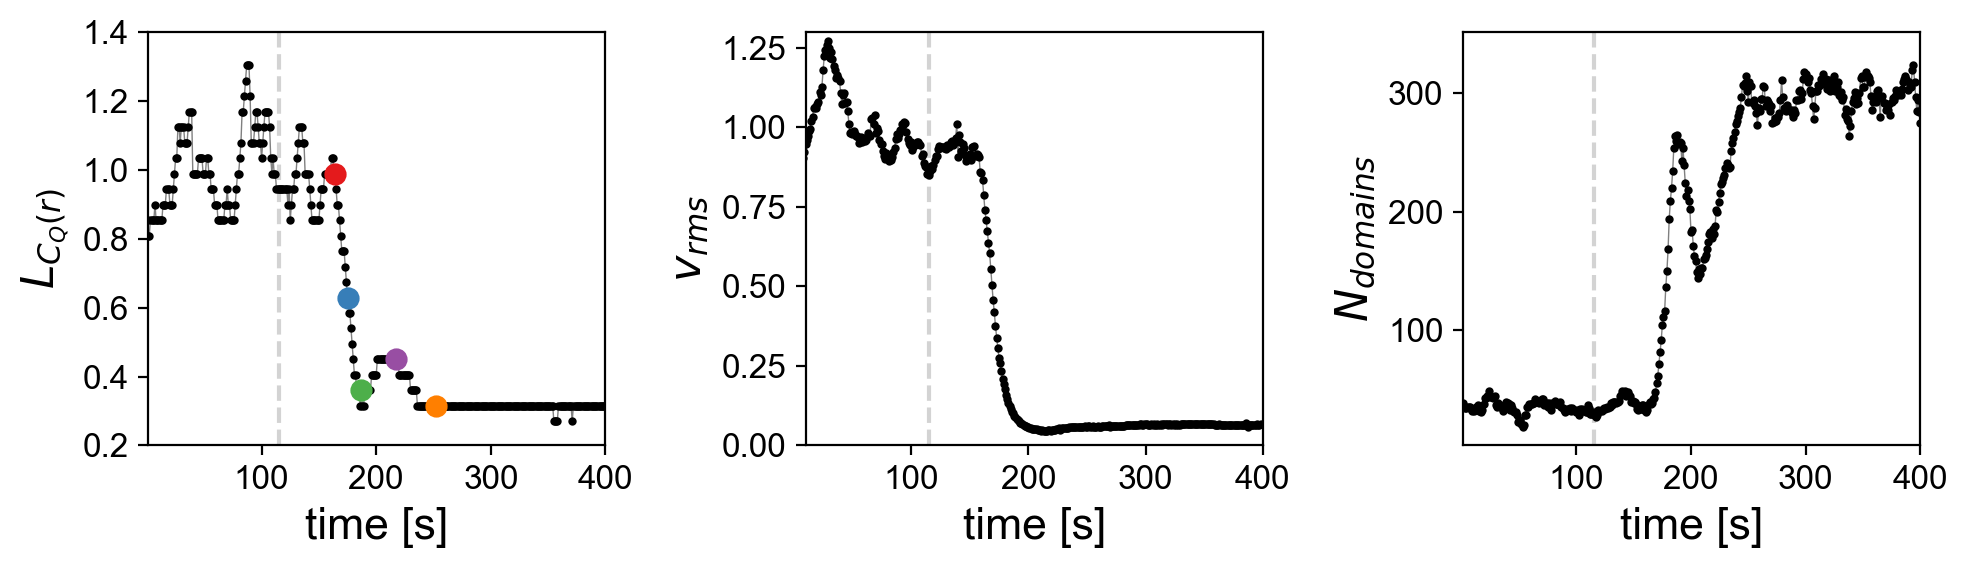

In [10]:
f,ax = plt.subplots(1,3, figsize=(10,3), dpi=200)

ax[0].axvline(x=115,color='lightgrey', lw=1.5, ls='--')
ax[0].plot(Clen/norm_c, color='grey',marker='.', markerfacecolor='k',markeredgecolor='k',markersize=4, lw=0.5)
ax[0].plot(164, Clen[164]/norm_c, color='#e41a1c', marker='.',markerfacecolor='#e41a1c',markeredgecolor='#e41a1c',markersize=14)
ax[0].plot(175, Clen[175]/norm_c, color='#377eb8', marker='.',markerfacecolor='#377eb8',markeredgecolor='#377eb8',markersize=14)
ax[0].plot(187, Clen[187]/norm_c, color='#4daf4a', marker='.',markerfacecolor='#4daf4a',markeredgecolor='#4daf4a',markersize=14)
ax[0].plot(217, Clen[217]/norm_c, color='#984ea3', marker='.',markerfacecolor='#984ea3',markeredgecolor='#984ea3',markersize=14)
ax[0].plot(252, Clen[252]/norm_c, color='#ff7f00', marker='.',markerfacecolor='#ff7f00',markeredgecolor='#ff7f00',markersize=14)


ax[0].set_xlim([1,400])
ax[0].set_ylim([0.2,1.4])
ax[0].set_xlabel('time [s]', fontsize=16)
ax[0].set_ylabel('$L_{C_{Q}(r)}$', fontsize=16)
    

ax[1].axvline(x=115,color='lightgrey', lw=1.5, ls='--')
ax[1].plot(vrmsHH/norm_c_vrms, color='grey',marker='.', markerfacecolor='k',markeredgecolor='k',markersize=4, lw=0.5)
ax[1].set_xlim([10,400])
ax[1].set_ylim([0,1.3])
ax[1].set_xlabel('time [s]', fontsize=16)
ax[1].set_ylabel('$v_{rms}$', fontsize=16)

ax[2].axvline(x=115,color='lightgrey', lw=1.5, ls='--')
ax[2].plot(timeND,valsND, color='grey',marker='.', markerfacecolor='k',markeredgecolor='k',markersize=4, lw=0.5)
ax[2].set_xlim([1,400])
ax[2].set_xlabel('time [s]', fontsize=16)
ax[2].set_ylabel('$N_{domains}$', fontsize=16)
    

plt.tight_layout()

plt.savefig('./figs/fig1/1bcd.svg')
